# 02. Periodic variability

Same field as nb_01 (`Rubin_SV_225_-40`), `/home/shrra-ung/share/trieste/dia_object_lc_hq`.

- cleaned `diaObjectForcedSource.psfMag` (forced, every visit)
- `LombScargleMultiband`, `method='flexible'` (not `'fast'` — §4)
- top-3 peaks + power ratios + SNR + window-function check
- several-thousand-object candidate pool

## 0. Setup

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.timeseries import LombScargleMultiband
from scipy.signal import find_peaks

import lsdb
from lsst.utils.plotting import get_multiband_plot_colors, get_multiband_plot_symbols

filter_colors = get_multiband_plot_colors()
filter_symbols = get_multiband_plot_symbols()

In [2]:
DATA_DIR = Path("/home/shrra-ung/share/trieste") # sorry, the data lives in 'Trieste' because I'm reusing stuff
hq_path = DATA_DIR / "dia_object_lc_hq"
hq_cat = lsdb.open_catalog(hq_path)
print(hq_cat.npartitions, "partitions")

4445 partitions


## Backup (in case RSP is slow)

Sections 1-5 below cache to `/home/shrra-ung/share/trieste/dia_object_lc_hq_field_sample.parquet` (written at the end of §5). Flip `USE_BACKUP = True` to load it and skip the ~9 min of live computation (236s cleaning pass + 245s amplitude pass + 71s LS).

In [12]:
USE_BACKUP = True
BACKUP_PATH = DATA_DIR / "dia_object_lc_hq_field_sample.parquet"

if USE_BACKUP:
    backup_df = pd.read_parquet(BACKUP_PATH)
    lcs = {row['diaObjectId']: (np.array(row['t']), np.array(row['mag']), np.array(row['band']))
           for _, row in backup_df.iterrows()}
    results = backup_df.drop(columns=['t', 'mag', 'band'])
    print(f"loaded {len(results)} objects from backup, period calculation will be skipped")

loaded 116 objects from backup, period calculation will be skipped


## 1. Candidate pool

In [13]:
field_ra, field_dec = 225.0, -39.5
pool_radius_arcsec = 0.29 * 3600

t0 = time.time()
field_df = hq_cat.cone_search(ra=field_ra, dec=field_dec, radius_arcsec=pool_radius_arcsec).compute()
print(f"{len(field_df)} objects, {time.time()-t0:.1f}s")

Computing Catalog:   0%|          | 0/198 [00:00<?, ?it/s]

4005 objects, 4.6s


## 2. Cleaning: pixel flags + per-point SNR

- nb_01 §6's `science_okflag` recipe, plus `psfFlux/psfFluxErr > 5`
- using flags alone misses marginal-SNR points and `-2.5 log10(psfFlux)` blows up near zero flux, so SNR filtering is used
- a real case: a 2.9-mag "amplitude" object that was psfMag 19-31 noise, not a source
- the flag-filtering is saved as a mask

In [14]:
FLAG_COLS = ['psfFlux_flag', 'pixelFlags_bad', 'pixelFlags_saturatedCenter', 'invalidPsfFlag']
MIN_SNR = 5.0

def clean_lc(fs):
    """fs: one object's diaObjectForcedSource nested row -> (t, mag, band), quality-cut."""
    ok = np.ones(len(fs), dtype=bool)
    for c in FLAG_COLS:
        ok &= ~fs[c].to_numpy()
    flux = fs['psfFlux'].to_numpy()
    fluxerr = fs['psfFluxErr'].to_numpy()
    snr = flux / fluxerr
    ok &= np.isfinite(snr) & (snr > MIN_SNR)
    t = fs['midpointMjdTai'].to_numpy()
    mag = fs['psfMag'].to_numpy()
    band = fs['band'].to_numpy()
    ok &= np.isfinite(t) & np.isfinite(mag)
    return t[ok], mag[ok], band[ok]

## 3. Pre-filter: enough clean points, then amplitude

- SNR+flag cleaning over the whole pool first
- for this field, SNR filtering does not remove too many observations, but for other fields it needs checking

In [15]:
MIN_POINTS = 100

if not USE_BACKUP:
    t0 = time.time()
    n_clean = np.zeros(len(field_df), dtype=int)
    for i in range(len(field_df)):
        t, mag, band = clean_lc(field_df.iloc[i]['diaObjectForcedSource'])
        n_clean[i] = len(t)
    print(f"cleaning pass: {len(field_df)} objects, {time.time()-t0:.1f}s")
    print(f"n_clean >= {MIN_POINTS}: {np.sum(n_clean >= MIN_POINTS)}/{len(field_df)} "
          f"(median n_clean = {np.median(n_clean):.0f})")
# Output is something like:
# cleaning pass: 4005 objects, 233.8s
# n_clean >= 100: 3996/4005 (median n_clean = 1680)

In [16]:
def robust_amp_stat(t, mag, band, nsigma=5.0):
    """Median across bands of the 5-sigma-clipped (MAD) p90-p10 magnitude range."""
    amps = []
    for b in np.unique(band):
        m = mag[band == b]
        if len(m) < 5:
            continue
        med = np.median(m)
        mad = np.median(np.abs(m - med)) * 1.4826
        clipped = m[np.abs(m - med) < nsigma * mad] if mad > 0 else m
        if len(clipped) < 5:
            clipped = m
        amps.append(np.percentile(clipped, 90) - np.percentile(clipped, 10))
    return np.median(amps) if amps else np.nan

In [17]:
MIN_AMP_MAG = 0.3  # ~0.2 mag (typical of this field) is too small for this workshop

if not USE_BACKUP:
    t0 = time.time()
    lcs = {}
    for i in np.where(n_clean >= MIN_POINTS)[0]:
        r = field_df.iloc[i]
        t, mag, band = clean_lc(r['diaObjectForcedSource'])
        amp = robust_amp_stat(t, mag, band)
        if amp > MIN_AMP_MAG:
            lcs[r['diaObjectId']] = (t, mag, band)
    print(f"amplitude pass: {time.time()-t0:.1f}s -- {len(lcs)} final candidates "
          f"(n_clean >= {MIN_POINTS} AND amp > {MIN_AMP_MAG})")

## 4. Multiband Lomb-Scargle. SNR and window-function check

- `method='fast'` fabricates power: power=91 (impossible, standard norm. bounded ≤1) where `'flexible'` gives 0.02 on the same data
- `method='flexible'`, coarser grid (`samples_per_peak=1`, period floor 0.2 d): ~0.3-0.8s/object vs. 16.6s/object
- power SNR: peak power vs. that object's own periodogram noise floor (median + MAD)
- window function: |Σ exp(-2πi f t)|²/N². Calculated once per cadence; a peak on a strong window peak is the sampling, not the source

In [18]:
MIN_PERIOD_DAYS = 0.2
N_PEAKS = 3

def spectral_window_power(t, freq):
    phase = 2 * np.pi * np.outer(freq, t)
    c, s = np.cos(phase).sum(axis=1), np.sin(phase).sum(axis=1)
    return (c**2 + s**2) / len(t)**2

def top_peaks(t, mag, band):
    """Top-3 local maxima: periods, powers, SNRs, window power at each -> dict, or None."""
    duration = t.max() - t.min()
    max_period = duration / 2  # >=2 cycles must fit in the baseline
    if max_period <= MIN_PERIOD_DAYS:
        return None
    ls = LombScargleMultiband(t, mag, band)
    freq, power = ls.autopower(minimum_frequency=1 / max_period, maximum_frequency=1 / MIN_PERIOD_DAYS,
                               samples_per_peak=1, method='flexible')
    peak_idx, _ = find_peaks(power)
    if len(peak_idx) == 0:
        return None
    top = peak_idx[np.argsort(power[peak_idx])[::-1][:N_PEAKS]]
    med_p = np.median(power)
    mad_p = np.median(np.abs(power - med_p)) * 1.4826
    return {
        'periods': 1 / freq[top], 'powers': power[top],
        'snr': (power[top] - med_p) / mad_p if mad_p > 0 else np.full(len(top), np.nan),
        'window': spectral_window_power(t, freq[top]),
    }

## 5. Run on the final candidates

In [19]:
if not USE_BACKUP:
    rows = []
    t0 = time.time()
    for oid, (t, mag, band) in lcs.items():
        rec = {'diaObjectId': oid, 'n_clean': len(t)}
        res = top_peaks(t, mag, band)
        if res is not None:
            periods, powers, snr, window = res['periods'], res['powers'], res['snr'], res['window']
            for k in range(N_PEAKS):
                if k < len(periods):
                    rec[f'period_{k+1}'] = periods[k]
                    rec[f'power_{k+1}'] = powers[k]
                    rec[f'snr_{k+1}'] = snr[k]
                    rec[f'window_{k+1}'] = window[k]
            if len(powers) > 1:
                rec['power_ratio_21'] = powers[1] / powers[0]
            if len(powers) > 2:
                rec['power_ratio_31'] = powers[2] / powers[0]
        rows.append(rec)
    results = pd.DataFrame(rows)
    print(f"{len(lcs)} candidates in {time.time()-t0:.1f}s")

results.sort_values('power_1', ascending=False).head(20)

,diaObjectId,n_clean,period_1,power_1,snr_1,window_1,period_2,power_2,snr_2,window_2,period_3,power_3,snr_3,window_3,power_ratio_21,power_ratio_31
76,744856867972317323,1652,0.557933,0.822880,10.607448,0.023602,0.357707,0.724790,9.091845,0.019755,1.267304,0.661321,8.111177,0.013597,0.880796,0.803666
81,744857555167086745,1545,0.987530,0.599314,4.781390,0.056547,0.396658,0.509408,3.704380,0.126529,1.762925,0.498137,3.569368,0.001304,0.849985,0.831180
69,744857623886563467,1617,0.392731,0.523772,4.454831,0.010480,0.736826,0.509168,4.281203,0.024145,1.166641,0.507204,4.257854,0.072772,0.972118,0.968368
97,744858311081329958,1548,79.331610,0.519497,4.188970,0.025953,0.345421,0.510696,4.088212,0.041589,0.256737,0.496693,3.927894,0.020183,0.983058,0.956102
6,744856867972318093,1609,0.898094,0.510762,5.007876,0.074584,0.472212,0.462932,4.365971,0.057771,1.160950,0.414288,3.713143,0.073573,0.906356,0.811118
19,744856867972317899,1675,1.160950,0.495110,4.530191,0.079941,0.392731,0.454508,4.017018,0.010173,6.999848,0.446490,3.915673,0.126311,0.917995,0.901800
68,744857623886562277,1670,1.166641,0.490825,4.625232,0.065234,0.392731,0.442512,3.986668,0.009763,0.648487,0.411873,3.581711,0.031373,0.901567,0.839144
71,744857623886562414,1664,1.166641,0.486288,4.771702,0.070044,0.392731,0.438311,4.104467,0.011579,0.280986,0.420388,3.855197,0.008654,0.901341,0.864483
72,744857623886562276,1671,1.166641,0.485954,4.506364,0.070852,0.392731,0.455714,4.106674,0.012251,0.219350,0.444813,3.962595,0.043320,0.937771,0.915339
17,744856867972323667,1651,1.166641,0.480254,4.725610,0.073472,0.392731,0.412860,3.801087,0.008281,0.736826,0.412252,3.792748,0.024206,0.859670,0.858404


In [20]:
# If you do it yourself, change BACKUP_PATH in the last two lines to your own path
if not USE_BACKUP:
    backup_df = results.copy()
    backup_df['t'] = [lcs[oid][0].tolist() for oid in backup_df['diaObjectId']]
    backup_df['mag'] = [lcs[oid][1].tolist() for oid in backup_df['diaObjectId']]
    backup_df['band'] = [lcs[oid][2].tolist() for oid in backup_df['diaObjectId']]
    backup_df.to_parquet(BACKUP_PATH) 
    print(f"backup saved: {BACKUP_PATH} ({len(backup_df)} objects)")

- `period_1` ≈ 1.1666 d for most of the top 20. It matches to 4-5 decimals across unrelated objects, power ratios 0.85-0.99 (flat periodogram, alias signature) -> field-specific nightly-cadence alias.
- One object stands apart: `744856867972317323` — SNR 10.6 (next-best ~5), window power 0.01-0.02 across all 3 peaks (~5x below the alias group). Plotted below.

(0.0, 1.5)

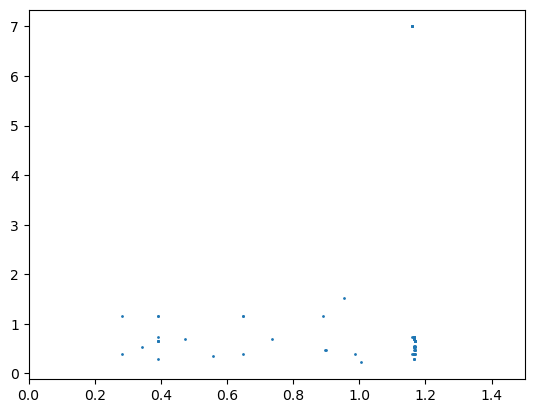

In [21]:
plt.scatter(results['period_1'],results['period_2'],s=1)
plt.xlim(0,1.5)

In [22]:
results[results['snr_1']>10]

,diaObjectId,n_clean,period_1,power_1,snr_1,window_1,period_2,power_2,snr_2,window_2,period_3,power_3,snr_3,window_3,power_ratio_21,power_ratio_31
76,744856867972317323,1652,0.557933,0.82288,10.607448,0.023602,0.357707,0.72479,9.091845,0.019755,1.267304,0.661321,8.111177,0.013597,0.880796,0.803666


## 6. Light curve for the standout candidate

In [ ]:
best_id = 744856867972317323
t, mag, band = lcs[best_id]
row = results[results['diaObjectId'] == best_id].iloc[0]
period = row['period_1']
print(f"diaObjectId={best_id}  period_1={period:.4f} d  power_1={row['power_1']:.3f}  "
      f"snr_1={row['snr_1']:.1f}  window_1={row['window_1']:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for b in filter_colors:
    m = band == b
    if m.sum() == 0:
        continue
    ax1.plot(t[m], mag[m], filter_symbols[b], color=filter_colors[b], ms=4, mew=0, alpha=0.6, label=b)
    phase = np.mod(t[m] / period, 1.0)
    ax2.plot(phase, mag[m], filter_symbols[b], color=filter_colors[b], ms=4, mew=0, alpha=0.6)
ax1.invert_yaxis(); ax1.set_xlabel('MJD'); ax1.set_ylabel('psfMag'); ax1.legend(ncol=3, fontsize=8)
ax2.invert_yaxis(); ax2.set_xlabel('phase'); ax2.set_title(f'folded at {period:.4f} d')
plt.tight_layout()
plt.show()

## 7. Is this a known variable?

- r~20, bright enough to already be catalogued
- cross-match by coordinates: GCVS, AAVSO VSX, ASAS-SN variables, SIMBAD, Gaia DR3
- OGLE skipped: VizieR's OGLE catalogs cover only the Bulge/Magellanic Clouds/a few dwarf galaxies, not (225,-40)

In [ ]:
from astroquery.vizier import Vizier
from astroquery.simbad import Simbad
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u

# diaObjectId exceeds float64 precision -- column access only, no row view (see §8)
mask = field_df['diaObjectId'] == best_id
target_ra = field_df.loc[mask, 'ra'].iloc[0]
target_dec = field_df.loc[mask, 'dec'].iloc[0]
coord = SkyCoord(ra=target_ra * u.deg, dec=target_dec * u.deg)
print(f"target: RA={target_ra:.5f} Dec={target_dec:.5f}")

In [ ]:
search_radius = 15 * u.arcsec
vizier = Vizier(columns=['*'])

for catalog_id, label in [("B/gcvs/gcvs_cat", "GCVS"), ("B/vsx/vsx", "AAVSO VSX"),
                          ("II/366/catalog", "ASAS-SN variables")]:
    result = vizier.query_region(coord, radius=search_radius, catalog=catalog_id)
    n = len(result[0]) if len(result) else 0
    print(f"{label}: {n} match(es) within {search_radius}")

simbad_result = Simbad.query_region(coord, radius=search_radius)
print(f"SIMBAD: {len(simbad_result) if simbad_result is not None else 0} match(es) within {search_radius}")

Gaia DR3 directly (not the VizieR mirror) — variability flag and raw detection both, since those are different findings.

In [ ]:
Gaia.ROW_LIMIT = 20
gaia_query = f"""SELECT source_id, ra, dec, phot_g_mean_mag, phot_variable_flag
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec),
                 CIRCLE('ICRS', {target_ra}, {target_dec}, {(search_radius.to(u.deg)).value}))"""
gaia_result = Gaia.launch_job(gaia_query).get_results()
print(f"Gaia DR3: {len(gaia_result)} source(s) within {search_radius}")
gaia_result

- not in GCVS, VSX, ASAS-SN, or SIMBAD
- Gaia DR3 detects a source at this position (sub-arcsec, G ~ 20.1, matches r ~ 20) but `phot_variable_flag = NOT_AVAILABLE` (too shallow for Gaia, or not enough observations? Needs to be checked)

## 8. Full periodograms, side by side with the window function

Top-3 peaks ranks candidates; doesn't show how the window shapes the whole spectrum.

**Pandas note:** `diaObjectId` (int64, ~7e17) exceeds float64's exact range (2^53) — `.iloc[0]` on a row mixed with float columns can silently corrupt it (`...317323` -> `...317312`, no error), not just crash. Pull the id column out on its own instead (below); casting to string works too. (If someone knows a better way of doing this, please tell me - some of my Gaia-based cats have 'str' ids for all 200 million of objects...)

In [ ]:
showcase_ids = [744856867972317323, 744857623886562277, 744857555167086745]
showcase_labels = ["standout candidate", "alias-cluster member (1.166 d)", "ambiguous case"]

fig, axes = plt.subplots(len(showcase_ids), 2, figsize=(12, 3.3 * len(showcase_ids)), sharex='col')
for row, (oid, label) in enumerate(zip(showcase_ids, showcase_labels)):
    t, mag, band = lcs[oid]
    max_period = (t.max() - t.min()) / 2
    ls = LombScargleMultiband(t, mag, band)
    freq, power = ls.autopower(minimum_frequency=1 / max_period, maximum_frequency=1 / MIN_PERIOD_DAYS,
                               samples_per_peak=1, method='flexible')
    window = spectral_window_power(t, freq)
    periods = 1 / freq

    axes[row, 0].plot(periods, power, lw=0.8, color='C0')
    axes[row, 0].set_ylabel(f"{label}\npower")
    axes[row, 1].plot(periods, window, lw=0.8, color='C1')
    axes[row, 1].set_ylabel("window power")
    for ax in axes[row]:
        ax.set_xscale('log')

axes[0, 0].set_title("LS periodogram (multiband)")
axes[0, 1].set_title("window function")
axes[-1, 0].set_xlabel("period (d)")
axes[-1, 1].set_xlabel("period (d)")
plt.tight_layout()
plt.show()

- window function nearly identical for all three (shared sampling): sharp spikes at 1.0 d and 0.5 d, the classic diurnal alias
- the whole periodogram's broad shape tracks the window's shape in all three, signal or not
- standout candidate: one isolated peak, clear of both spikes
- the other two: tallest peak sits on or next to a window spike